# Exploratory Data Analysis - Dataset-02 (BRSET Retinal Fundus Images)

This notebook performs a comprehensive EDA on Dataset-02, a clinical retinal fundus image dataset with 34 columns of metadata including DR grading (ICDR scale), patient demographics, comorbidities, and image quality indicators.

**Key Objectives:**
1. Understand data distribution and quality
2. Identify class imbalance in DR grading (DR_ICDR)
3. Analyze patient demographics and clinical features
4. Assess image quality and properties
5. Explore pathology co-occurrence patterns
6. Provide recommendations for model training

## 1. Setup & Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
DATA_DIR = os.path.join('..', 'dataset', 'Dataset-02', 'dataset_split')

TRAIN_CSV = os.path.join(DATA_DIR, 'train', 'train.csv')
VAL_CSV = os.path.join(DATA_DIR, 'val', 'val.csv')
TEST_CSV = os.path.join(DATA_DIR, 'test', 'test.csv')

TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train', 'images')
VAL_IMG_DIR = os.path.join(DATA_DIR, 'val', 'images')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test', 'images')

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f'Train: {len(train_df)} samples')
print(f'Val:   {len(val_df)} samples')
print(f'Test:  {len(test_df)} samples')
print(f'Total: {len(train_df) + len(val_df) + len(test_df)} samples')

Train: 13015 samples
Val:   1632 samples
Test:  1619 samples
Total: 16266 samples


## 3. Data Overview

In [17]:
print('=== Column Names and Data Types ===')
print(train_df.dtypes)
print(f'\nTotal columns: {len(train_df.columns)}')

=== Column Names and Data Types ===
image_id                     object
patient_id                    int64
camera                       object
patient_age                 float64
comorbidities                object
diabetes_time_y              object
insuline                     object
patient_sex                   int64
exam_eye                      int64
diabetes                     object
nationality                  object
optic_disc                    int64
vessels                       int64
macula                        int64
DR_SDRG                       int64
DR_ICDR                       int64
focus                         int64
Illuminaton                   int64
image_field                   int64
artifacts                     int64
diabetic_retinopathy          int64
macular_edema                 int64
scar                          int64
nevus                         int64
amd                           int64
vascular_occlusion            int64
hypertensive_retinopathy    

In [18]:
train_df.head(10)

,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
5,img00006,3,Canon CR,22.0,diabetes1,11,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
6,img00007,4,Canon CR,22.0,diabetes1,1,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
7,img00008,4,Canon CR,22.0,diabetes1,1,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
8,img00009,5,Canon CR,23.0,diabetes1,20,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
9,img00010,5,Canon CR,23.0,diabetes1,20,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate


In [19]:
train_df.describe(include='all')

,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
count,13015,13015.000000,13015,8669.000000,6396,1545,1381,13015.000000,13015.000000,13015,...,13015.000000,13015.000000,13015.000000,13015.000000,13015.000000,13015.000000,13015.000000,13015.000000,13015.000000,13015
unique,13015,NaN,2,NaN,184,50,2,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,img00001,NaN,Canon CR,NaN,0,10,yes,NaN,NaN,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adequate
freq,1,NaN,8516,NaN,2139,196,709,NaN,NaN,10936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11420
mean,NaN,4282.625509,NaN,57.911639,NaN,NaN,NaN,1.621975,1.498271,NaN,...,0.017211,0.006608,0.016980,0.170803,0.005763,0.000461,0.018517,0.199078,0.050173,NaN
std,NaN,2455.538320,NaN,18.252587,NaN,NaN,NaN,0.484913,0.500016,NaN,...,0.130062,0.081022,0.129203,0.376351,0.075696,0.021467,0.134817,0.399322,0.218310,NaN
min,NaN,1.000000,NaN,5.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2172.500000,NaN,47.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,4259.000000,NaN,61.000000,NaN,NaN,NaN,2.000000,1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,6439.000000,NaN,71.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


## 4. Data Quality Analysis

In [20]:
print('=== Missing Values (Train) ===')
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_info = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_info = missing_info[missing_info['Missing Count'] > 0]
if len(missing_info) > 0:
    print(missing_info.sort_values('Missing %', ascending=False))
else:
    print('No missing values found in training data.')

print(f'\n=== Duplicate Rows (Train) ===')
print(f'Duplicate rows: {train_df.duplicated().sum()}')
print(f'Duplicate image_ids: {train_df["image_id"].duplicated().sum()}')
print(f'Unique patients: {train_df["patient_id"].nunique()} (out of {len(train_df)} images)')

=== Missing Values (Train) ===
                 Missing Count  Missing %
insuline                 11634      89.39
diabetes_time_y          11470      88.13
comorbidities             6619      50.86
patient_age               4346      33.39

=== Duplicate Rows (Train) ===
Duplicate rows: 0
Duplicate image_ids: 0
Unique patients: 6819 (out of 13015 images)


In [21]:
print('=== Verify Image Files Exist ===')
train_images_on_disk = set(os.listdir(TRAIN_IMG_DIR))
train_images_in_csv = set(train_df['image_id'].apply(lambda x: f'{x}.jpg'))

missing_images = train_images_in_csv - train_images_on_disk
extra_images = train_images_on_disk - train_images_in_csv

print(f'Images in CSV: {len(train_images_in_csv)}')
print(f'Images on disk: {len(train_images_on_disk)}')
print(f'Missing from disk: {len(missing_images)}')
print(f'Extra on disk (not in CSV): {len(extra_images)}')

=== Verify Image Files Exist ===
Images in CSV: 13015
Images on disk: 13015
Missing from disk: 0
Extra on disk (not in CSV): 0


## 5. Target Variable Analysis - DR_ICDR (5-Class Grading)

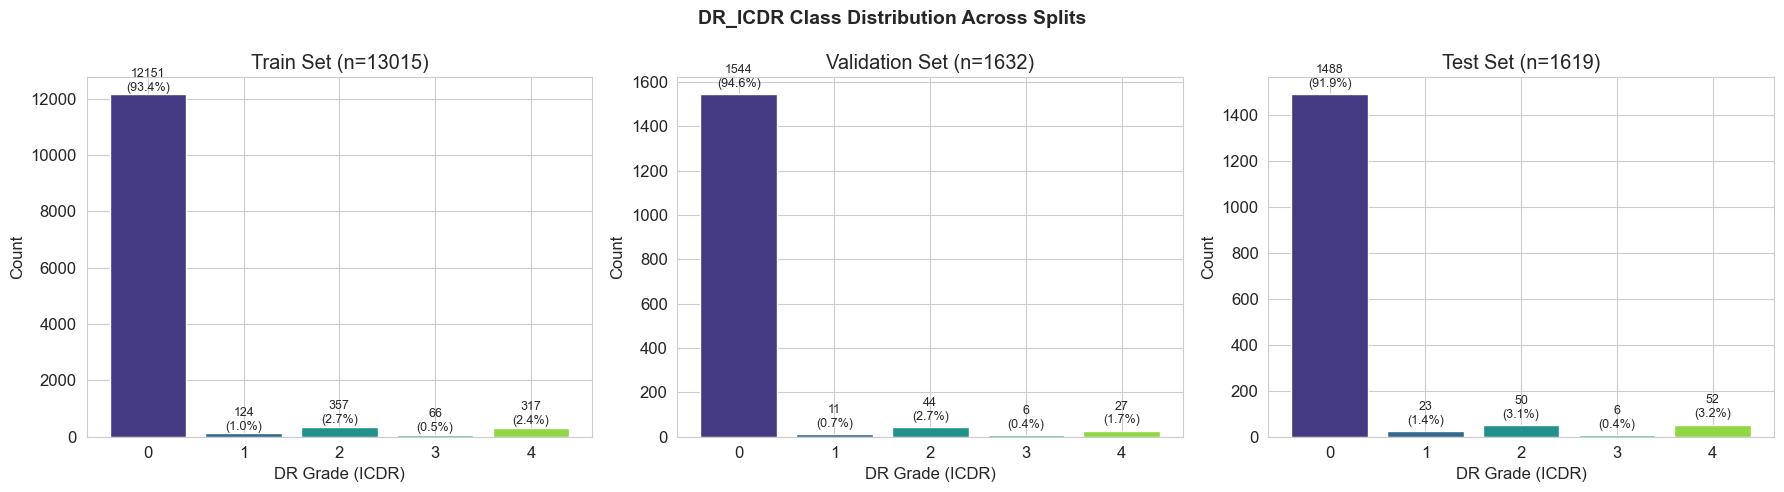

In [22]:
DR_LABELS = {
    0: 'No DR (Grade 0)',
    1: 'Mild NPDR (Grade 1)',
    2: 'Moderate NPDR (Grade 2)',
    3: 'Severe NPDR (Grade 3)',
    4: 'PDR (Grade 4)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, name) in zip(axes, [(train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test')]):
    counts = df['DR_ICDR'].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=sns.color_palette('viridis', 5))
    ax.set_xlabel('DR Grade (ICDR)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} Set (n={len(df)})')
    ax.set_xticks(range(5))
    for bar, count in zip(bars, counts.values):
        pct = count / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.suptitle('DR_ICDR Class Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_dr_icdr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Class Imbalance Analysis

In [23]:
print('=== Class Imbalance Metrics (Training Set) ===')
train_counts = train_df['DR_ICDR'].value_counts().sort_index()
total = train_counts.sum()
majority = train_counts.max()
minority = train_counts.min()

print(f'\nClass Distribution:')
for grade, count in train_counts.items():
    print(f'  Grade {grade} ({DR_LABELS[grade]}): {count:>6} ({count/total*100:.2f}%)')

print(f'\nImbalance Ratio (majority/minority): {majority/minority:.1f}x')
print(f'Majority class (Grade 0): {majority} samples ({majority/total*100:.1f}%)')
print(f'Minority class (Grade 3): {minority} samples ({minority/total*100:.1f}%)')

# Inverse frequency weights for weighted loss
class_counts = np.array([train_counts.get(i, 0) for i in range(5)])
class_weights = total / (5 * class_counts)
class_weights_normalized = class_weights / class_weights.sum() * 5

print(f'\nInverse Frequency Class Weights (raw): {np.round(class_weights, 4)}')
print(f'Normalized Class Weights: {np.round(class_weights_normalized, 4)}')

=== Class Imbalance Metrics (Training Set) ===

Class Distribution:
  Grade 0 (No DR (Grade 0)):  12151 (93.36%)
  Grade 1 (Mild NPDR (Grade 1)):    124 (0.95%)
  Grade 2 (Moderate NPDR (Grade 2)):    357 (2.74%)
  Grade 3 (Severe NPDR (Grade 3)):     66 (0.51%)
  Grade 4 (PDR (Grade 4)):    317 (2.44%)

Imbalance Ratio (majority/minority): 184.1x
Majority class (Grade 0): 12151 samples (93.4%)
Minority class (Grade 3): 66 samples (0.5%)

Inverse Frequency Class Weights (raw): [ 0.2142 20.9919  7.2913 39.4394  8.2114]
Normalized Class Weights: [0.0141 1.3784 0.4788 2.5896 0.5392]


In [24]:
# Binary grouping: Benign (Grade 0) vs Malignant (Grades 1-4)
print('=== Binary Class Distribution (Benign vs Malignant) ===')
for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    benign = (df['DR_ICDR'] == 0).sum()
    malignant = (df['DR_ICDR'] > 0).sum()
    print(f'{name}: Benign={benign} ({benign/len(df)*100:.1f}%), '
          f'Malignant={malignant} ({malignant/len(df)*100:.1f}%), '
          f'Ratio={benign/malignant:.1f}:1')

=== Binary Class Distribution (Benign vs Malignant) ===
Train: Benign=12151 (93.4%), Malignant=864 (6.6%), Ratio=14.1:1
Val: Benign=1544 (94.6%), Malignant=88 (5.4%), Ratio=17.5:1
Test: Benign=1488 (91.9%), Malignant=131 (8.1%), Ratio=11.4:1


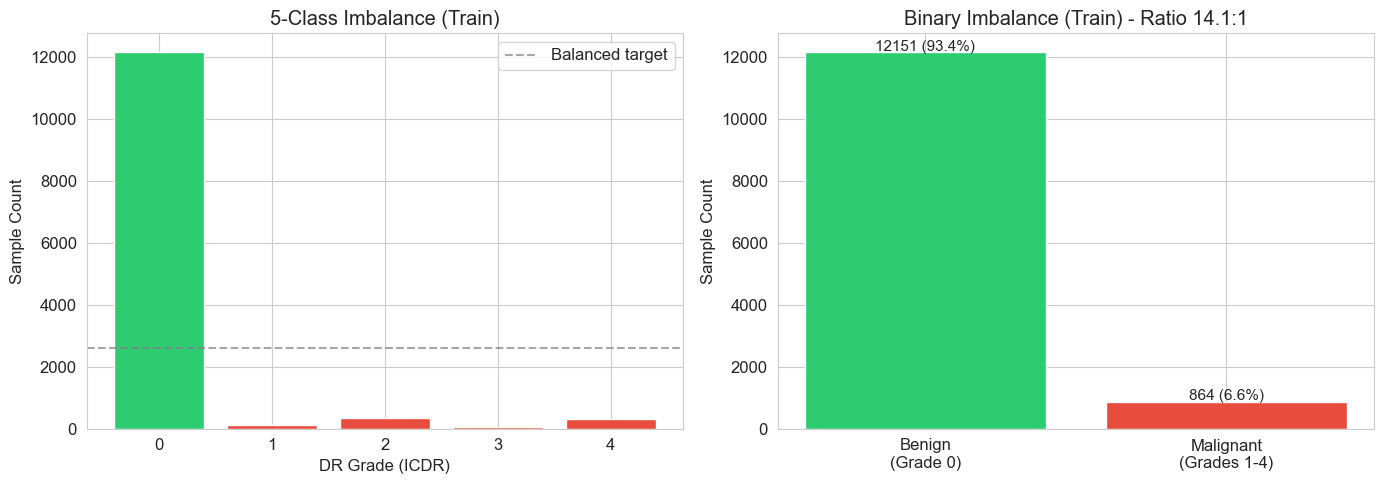

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5-class imbalance visualization
ax = axes[0]
colors = ['#2ecc71' if c == train_counts.max() else '#e74c3c' for c in train_counts.values]
bars = ax.bar(train_counts.index, train_counts.values, color=colors)
ax.set_xlabel('DR Grade (ICDR)')
ax.set_ylabel('Sample Count')
ax.set_title('5-Class Imbalance (Train)')
ax.set_xticks(range(5))
ax.axhline(y=total/5, color='gray', linestyle='--', alpha=0.7, label='Balanced target')
ax.legend()

# Binary imbalance visualization
ax = axes[1]
benign = (train_df['DR_ICDR'] == 0).sum()
malignant = (train_df['DR_ICDR'] > 0).sum()
bars = ax.bar(['Benign\n(Grade 0)', 'Malignant\n(Grades 1-4)'], [benign, malignant],
              color=['#2ecc71', '#e74c3c'])
for bar, val in zip(bars, [benign, malignant]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val} ({val/total*100:.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Sample Count')
ax.set_title(f'Binary Imbalance (Train) - Ratio {benign/malignant:.1f}:1')

plt.tight_layout()
plt.savefig('images/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Patient Demographics

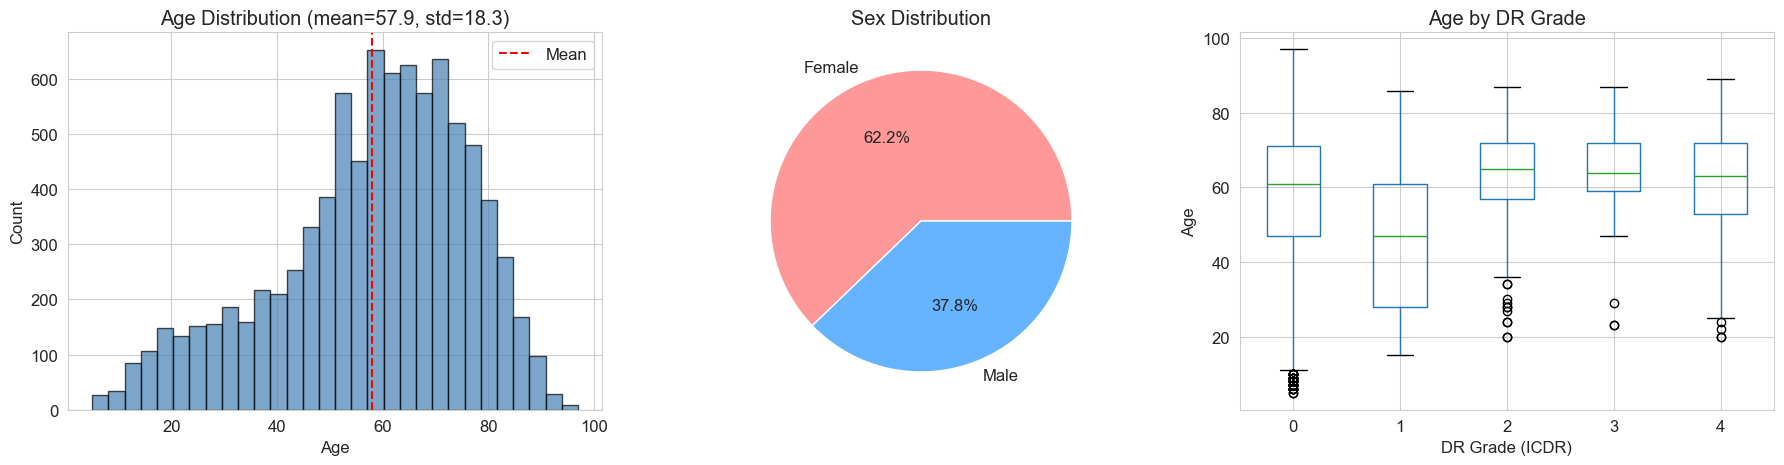

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
ax = axes[0]
train_df['patient_age'].hist(bins=30, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title(f'Age Distribution (mean={train_df["patient_age"].mean():.1f}, '
             f'std={train_df["patient_age"].std():.1f})')
ax.axvline(train_df['patient_age'].mean(), color='red', linestyle='--', label='Mean')
ax.legend()

# Sex distribution
ax = axes[1]
sex_counts = train_df['patient_sex'].value_counts()
sex_labels = [{1: 'Male', 2: 'Female'}.get(v, str(v)) for v in sex_counts.index]
ax.pie(sex_counts.values, labels=sex_labels,
       autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
ax.set_title('Sex Distribution')

# Age by DR grade
ax = axes[2]
train_df.boxplot(column='patient_age', by='DR_ICDR', ax=ax)
ax.set_xlabel('DR Grade (ICDR)')
ax.set_ylabel('Age')
ax.set_title('Age by DR Grade')
plt.suptitle('')

plt.tight_layout()
plt.savefig('images/eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Eye distribution
print('=== Exam Eye Distribution ===')
print(train_df['exam_eye'].value_counts())

print('\n=== Diabetes Status ===')
print(train_df['diabetes'].value_counts())

print('\n=== Nationality ===')
print(train_df['nationality'].value_counts())

print('\n=== Camera Type ===')
print(train_df['camera'].value_counts())

=== Exam Eye Distribution ===
exam_eye
1    6530
2    6485
Name: count, dtype: int64

=== Diabetes Status ===
diabetes
No     10936
yes     2079
Name: count, dtype: int64

=== Nationality ===
nationality
Brazil    13015
Name: count, dtype: int64

=== Camera Type ===
camera
Canon CR        8516
NIKON NF5050    4499
Name: count, dtype: int64


## 8. Clinical Features Analysis

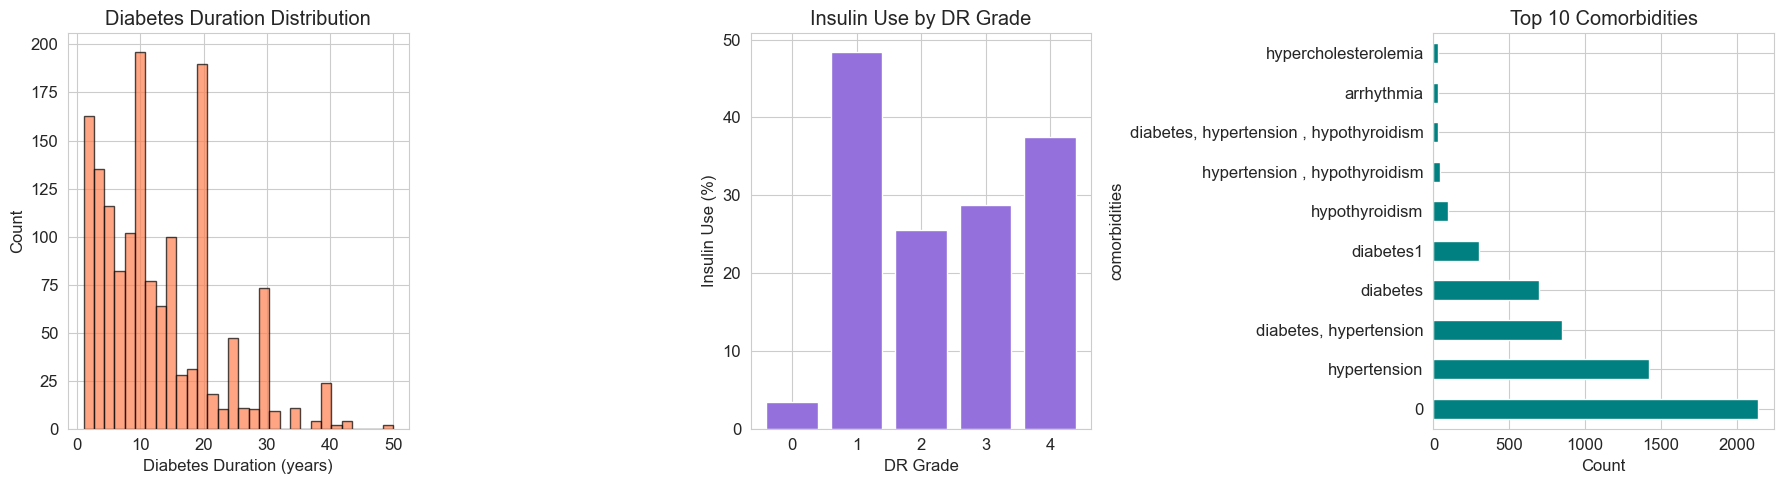

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Diabetes duration distribution
ax = axes[0]
diabetes_duration = pd.to_numeric(train_df['diabetes_time_y'], errors='coerce')
diabetes_duration.dropna().hist(bins=30, ax=ax, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Diabetes Duration (years)')
ax.set_ylabel('Count')
ax.set_title('Diabetes Duration Distribution')

# Insulin use by DR grade
ax = axes[1]
insulin_dr = train_df.groupby('DR_ICDR')['insuline'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).reset_index()
insulin_dr.columns = ['DR_ICDR', 'Insulin_Pct']
ax.bar(insulin_dr['DR_ICDR'], insulin_dr['Insulin_Pct'], color='mediumpurple')
ax.set_xlabel('DR Grade')
ax.set_ylabel('Insulin Use (%)')
ax.set_title('Insulin Use by DR Grade')
ax.set_xticks(range(5))

# Comorbidities distribution
ax = axes[2]
comorbidities = train_df['comorbidities'].value_counts().head(10)
comorbidities.plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Count')
ax.set_title('Top 10 Comorbidities')

plt.tight_layout()
plt.savefig('images/eda_clinical_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Diabetes duration by DR grade
print('=== Diabetes Duration by DR Grade ===')
train_df['diabetes_time_numeric'] = pd.to_numeric(train_df['diabetes_time_y'], errors='coerce')
print(train_df.groupby('DR_ICDR')['diabetes_time_numeric'].describe().round(2))

=== Diabetes Duration by DR Grade ===
          count   mean    std  min   25%   50%   75%   max
DR_ICDR                                                   
0        1108.0  10.40   7.97  1.0   4.0   9.5  15.0  41.0
1          67.0  17.91   6.52  3.0  14.0  17.0  21.0  37.0
2         151.0  17.95  10.04  2.0  10.0  18.0  24.0  50.0
3          33.0  18.09   9.21  5.0  13.0  15.0  20.0  40.0
4         150.0  22.15   9.50  1.0  15.0  20.0  30.0  43.0


## 9. Image Quality Assessment

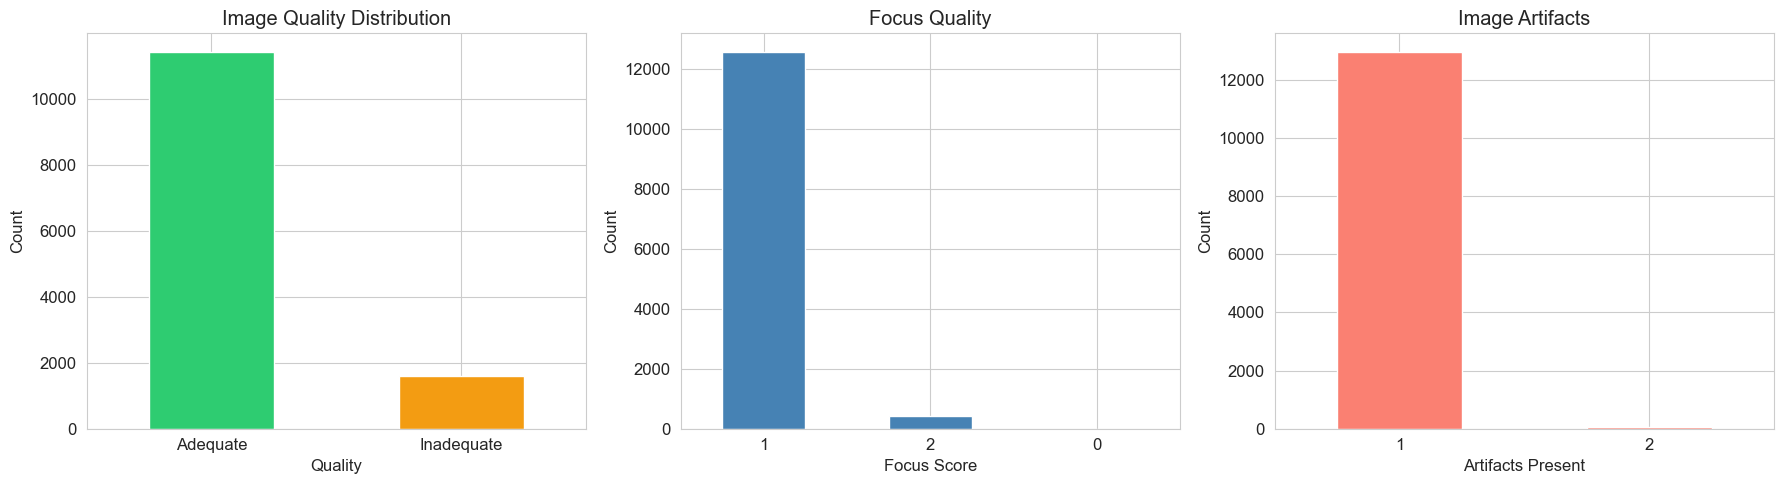

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quality distribution
ax = axes[0]
quality_counts = train_df['quality'].value_counts()
quality_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'][:len(quality_counts)])
ax.set_xlabel('Quality')
ax.set_ylabel('Count')
ax.set_title('Image Quality Distribution')
ax.tick_params(axis='x', rotation=0)

# Focus quality
ax = axes[1]
focus_counts = train_df['focus'].value_counts()
focus_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Focus Score')
ax.set_ylabel('Count')
ax.set_title('Focus Quality')
ax.tick_params(axis='x', rotation=0)

# Artifacts
ax = axes[2]
artifact_counts = train_df['artifacts'].value_counts()
artifact_counts.plot(kind='bar', ax=ax, color='salmon')
ax.set_xlabel('Artifacts Present')
ax.set_ylabel('Count')
ax.set_title('Image Artifacts')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('images/eda_image_quality.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Quality vs DR Grade crosstab
print('=== Image Quality by DR Grade ===')
quality_dr = pd.crosstab(train_df['quality'], train_df['DR_ICDR'], normalize='columns') * 100
print(quality_dr.round(1))

=== Image Quality by DR Grade ===
DR_ICDR        0     1     2     3     4
quality                                 
Adequate    87.5  91.1  90.2  95.5  91.8
Inadequate  12.5   8.9   9.8   4.5   8.2


## 10. Pathology Co-occurrence Analysis

In [32]:
pathology_cols = ['diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd',
                  'vascular_occlusion', 'hypertensive_retinopathy', 'drusens',
                  'hemorrhage', 'retinal_detachment', 'myopic_fundus',
                  'increased_cup_disc', 'other']

# Prevalence of each pathology
print('=== Pathology Prevalence (Training Set) ===')
for col in pathology_cols:
    positive = (train_df[col] > 0).sum()
    print(f'{col:>30}: {positive:>5} ({positive/len(train_df)*100:.2f}%)')

=== Pathology Prevalence (Training Set) ===
          diabetic_retinopathy:   856 (6.58%)
                 macular_edema:   321 (2.47%)
                          scar:   228 (1.75%)
                         nevus:   106 (0.81%)
                           amd:   224 (1.72%)
            vascular_occlusion:    86 (0.66%)
      hypertensive_retinopathy:   221 (1.70%)
                       drusens:  2223 (17.08%)
                    hemorrhage:    75 (0.58%)
            retinal_detachment:     6 (0.05%)
                 myopic_fundus:   241 (1.85%)
            increased_cup_disc:  2591 (19.91%)
                         other:   653 (5.02%)


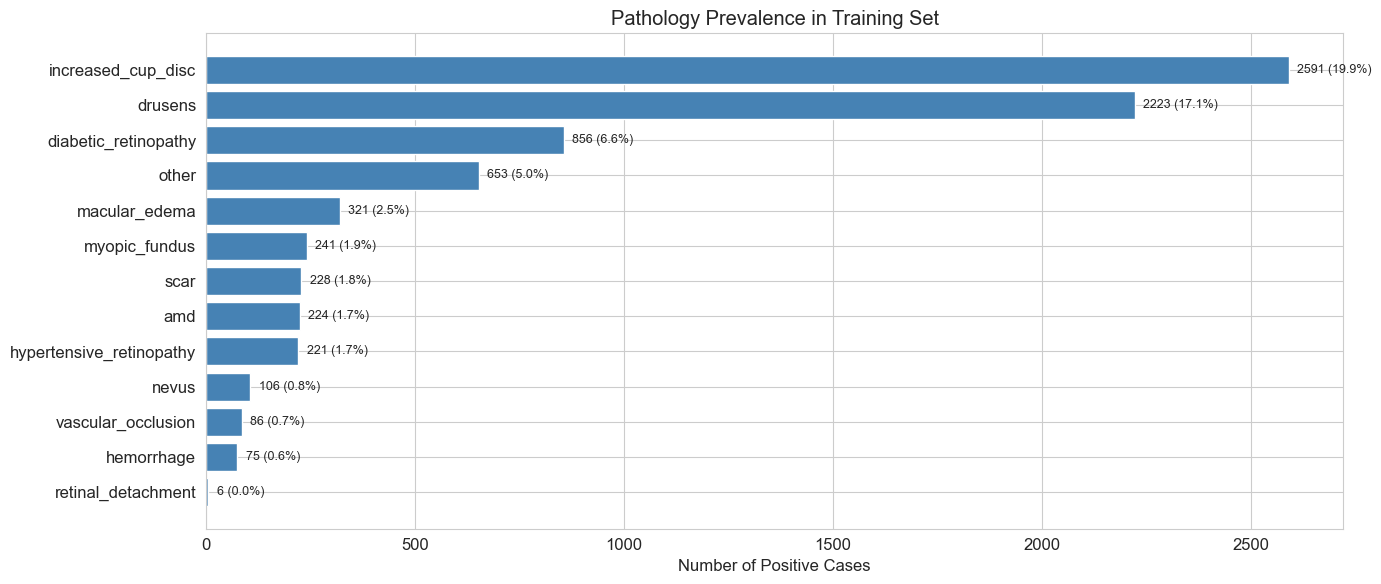

In [33]:
# Pathology prevalence bar chart
fig, ax = plt.subplots(figsize=(14, 6))
prevalence = [(col, (train_df[col] > 0).sum()) for col in pathology_cols]
prevalence.sort(key=lambda x: x[1], reverse=True)
names, counts = zip(*prevalence)

bars = ax.barh(range(len(names)), counts, color='steelblue')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Number of Positive Cases')
ax.set_title('Pathology Prevalence in Training Set')
ax.invert_yaxis()

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{count} ({count/len(train_df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/eda_pathology_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

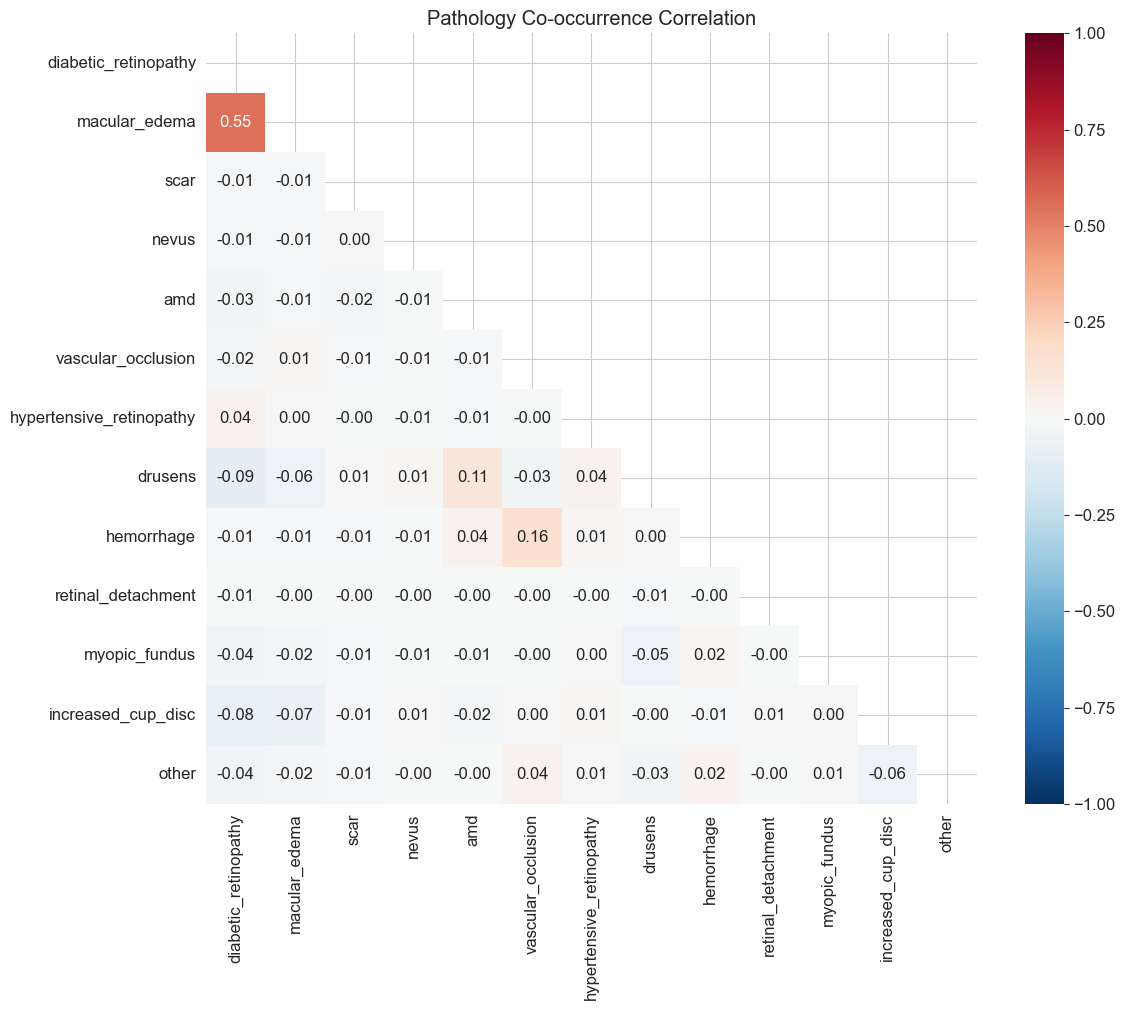

In [34]:
# Co-occurrence heatmap
fig, ax = plt.subplots(figsize=(12, 10))
pathology_binary = train_df[pathology_cols].apply(lambda x: (x > 0).astype(int))
corr = pathology_binary.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Pathology Co-occurrence Correlation')
plt.tight_layout()
plt.savefig('images/eda_pathology_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Anatomical Feature Analysis

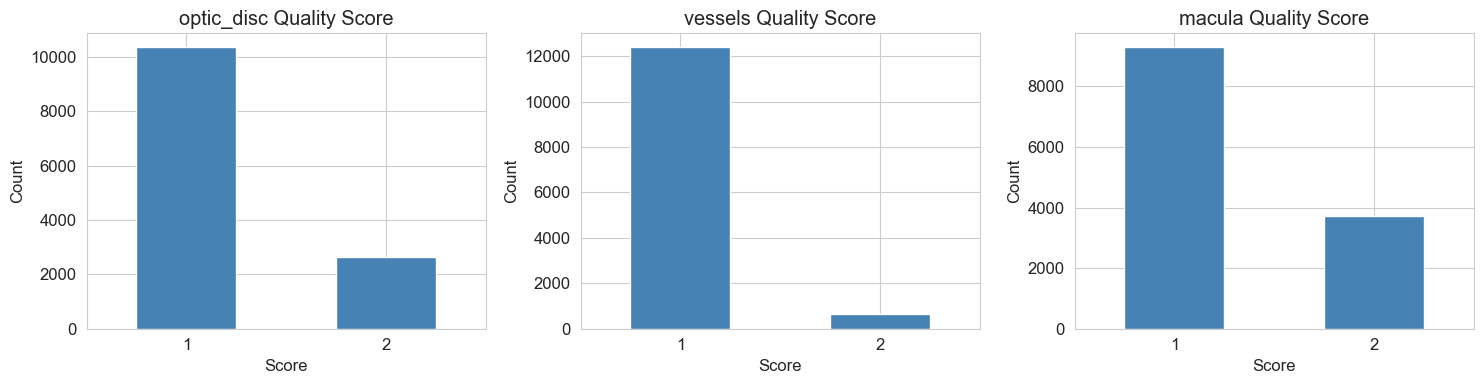

In [35]:
anatomical_cols = ['optic_disc', 'vessels', 'macula']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, anatomical_cols):
    counts = train_df[col].value_counts().sort_index()
    counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{col} Quality Score')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('images/eda_anatomical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Sample Image Visualization

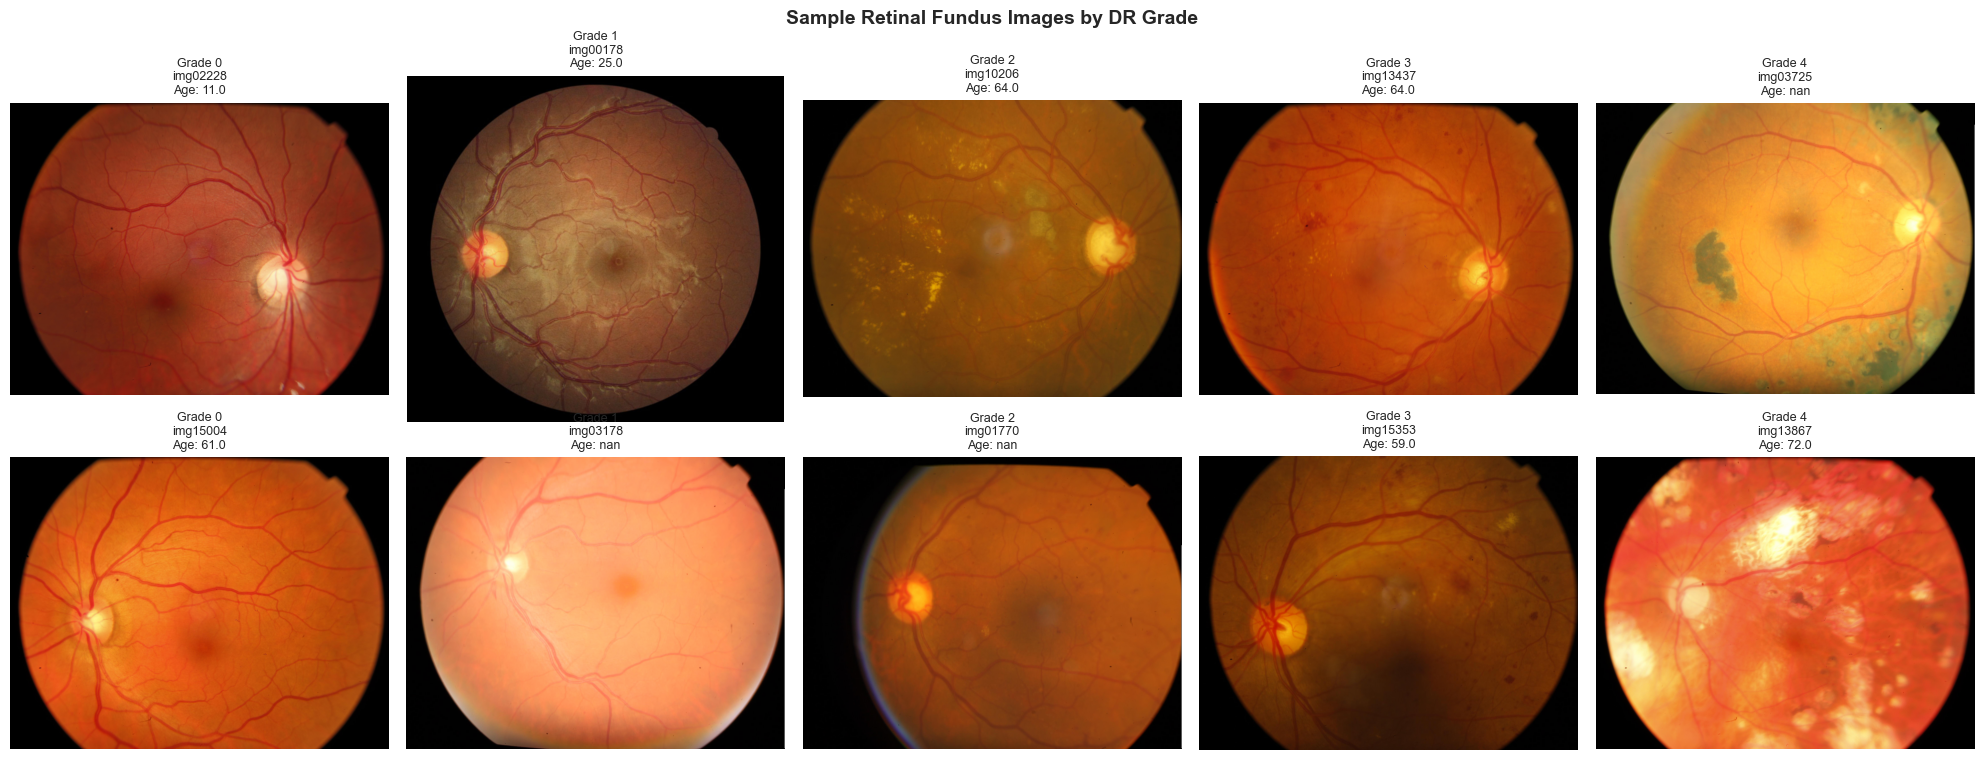

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for grade in range(5):
    grade_samples = train_df[train_df['DR_ICDR'] == grade].sample(n=min(2, len(train_df[train_df['DR_ICDR'] == grade])),
                                                                   random_state=42)
    for row_idx, (_, sample) in enumerate(grade_samples.iterrows()):
        img_path = os.path.join(TRAIN_IMG_DIR, f"{sample['image_id']}.jpg")
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[row_idx, grade].imshow(img)
            axes[row_idx, grade].set_title(f"Grade {grade}\n{sample['image_id']}\n"
                                           f"Age: {sample['patient_age']}", fontsize=9)
        axes[row_idx, grade].axis('off')

plt.suptitle('Sample Retinal Fundus Images by DR Grade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Image Properties Analysis

In [37]:
sample_size = min(500, len(train_df))
sample_ids = train_df.sample(n=sample_size, random_state=42)['image_id'].values

widths, heights, brightnesses = [], [], []

for img_id in sample_ids:
    img_path = os.path.join(TRAIN_IMG_DIR, f'{img_id}.jpg')
    if os.path.exists(img_path):
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
        img_arr = np.array(img)
        brightnesses.append(img_arr.mean())

print(f'=== Image Dimensions (sample of {sample_size}) ===')
print(f'Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')
print(f'Unique sizes: {len(set(zip(widths, heights)))}')
print(f'\nMean Brightness - min: {min(brightnesses):.1f}, max: {max(brightnesses):.1f}, '
      f'mean: {np.mean(brightnesses):.1f}')

=== Image Dimensions (sample of 500) ===
Width  - min: 951, max: 2984, mean: 2618
Height - min: 874, max: 2304, mean: 2032
Unique sizes: 5

Mean Brightness - min: 36.8, max: 146.3, mean: 86.4


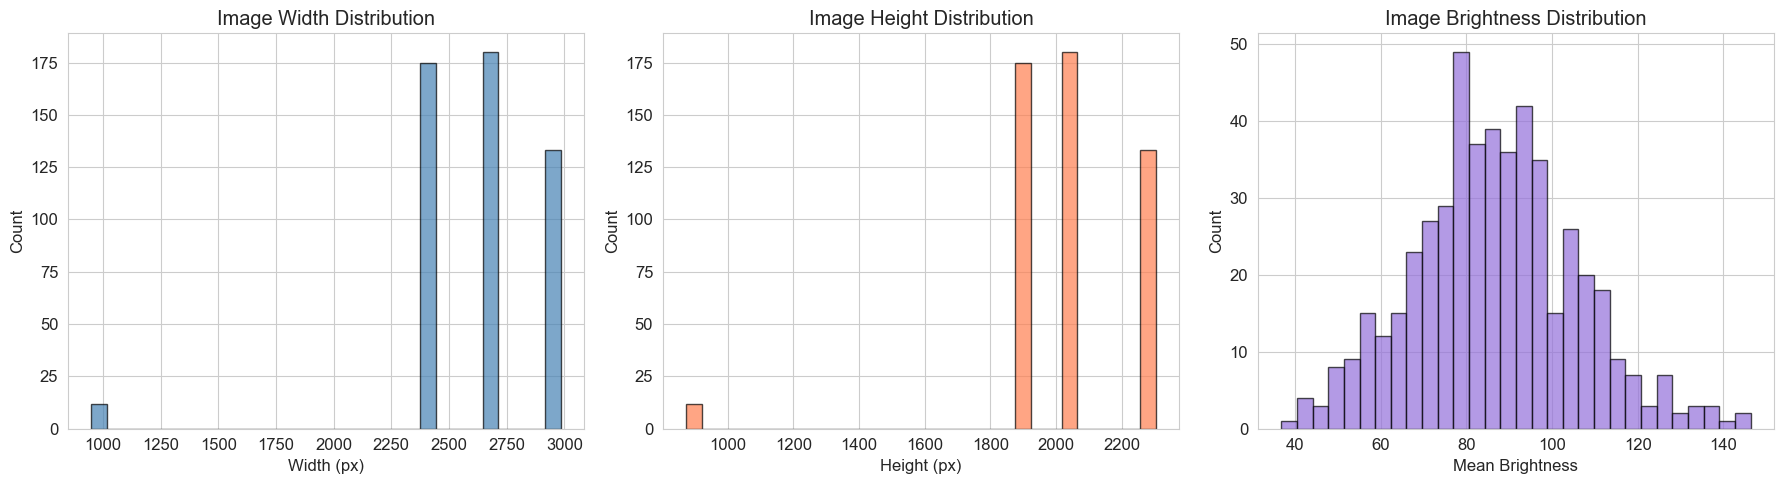

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].set_title('Image Width Distribution')

axes[1].hist(heights, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')
axes[1].set_title('Image Height Distribution')

axes[2].hist(brightnesses, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Mean Brightness')
axes[2].set_ylabel('Count')
axes[2].set_title('Image Brightness Distribution')

plt.tight_layout()
plt.savefig('images/eda_image_properties.png', dpi=150, bbox_inches='tight')
plt.show()

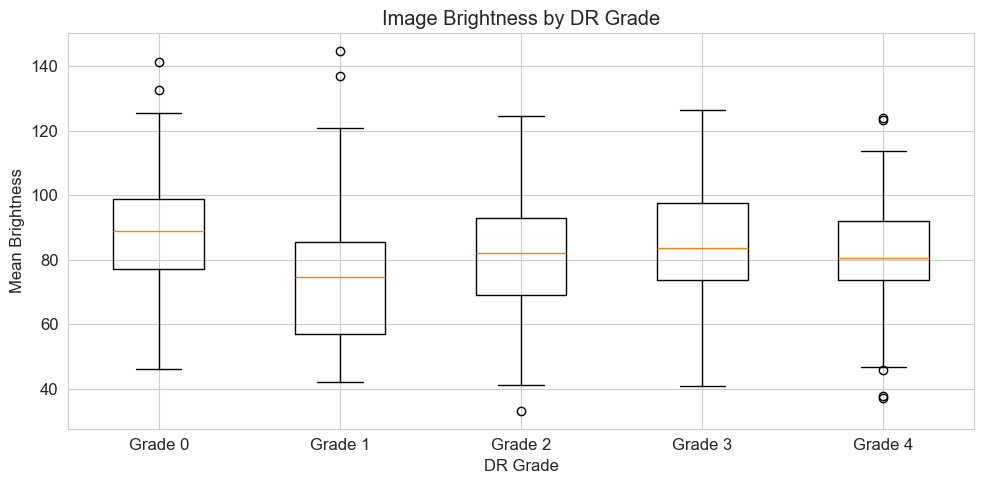

In [39]:
# Brightness by DR grade
grade_brightness = {}
for grade in range(5):
    grade_ids = train_df[train_df['DR_ICDR'] == grade].sample(
        n=min(100, len(train_df[train_df['DR_ICDR'] == grade])), random_state=42
    )['image_id'].values
    b = []
    for img_id in grade_ids:
        img_path = os.path.join(TRAIN_IMG_DIR, f'{img_id}.jpg')
        if os.path.exists(img_path):
            b.append(np.array(Image.open(img_path)).mean())
    grade_brightness[grade] = b

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([grade_brightness[g] for g in range(5)], labels=[f'Grade {g}' for g in range(5)])
ax.set_xlabel('DR Grade')
ax.set_ylabel('Mean Brightness')
ax.set_title('Image Brightness by DR Grade')
plt.tight_layout()
plt.savefig('images/eda_brightness_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. DR Grade vs Clinical Features Cross-Analysis

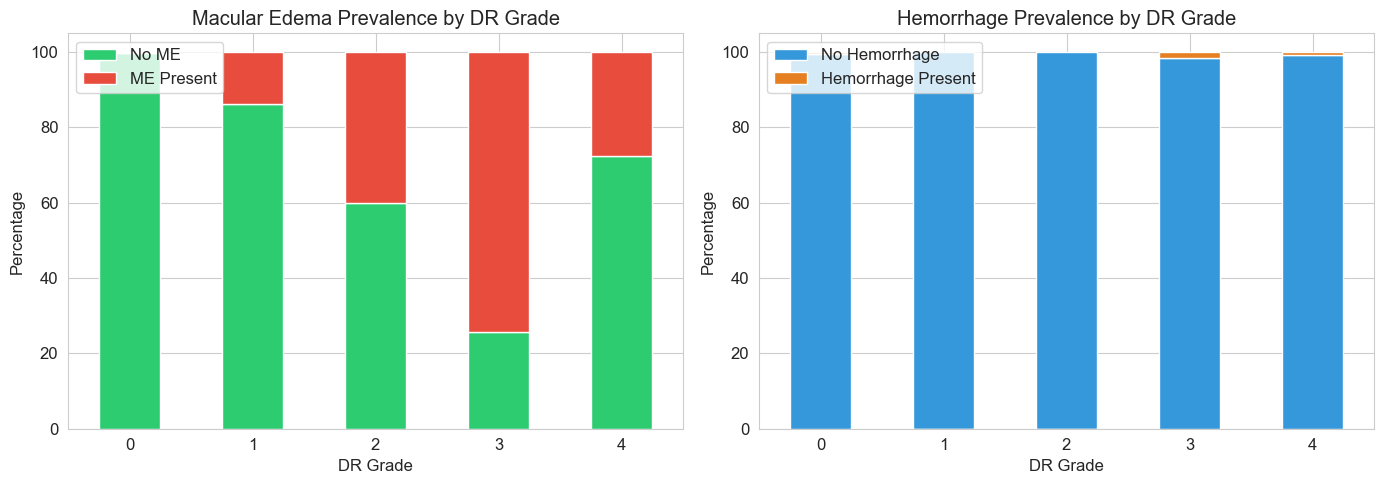

In [40]:
# Macular edema by DR grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
me_by_dr = pd.crosstab(train_df['DR_ICDR'], train_df['macular_edema'] > 0, normalize='index') * 100
me_by_dr.columns = ['No ME', 'ME Present']
me_by_dr.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xlabel('DR Grade')
ax.set_ylabel('Percentage')
ax.set_title('Macular Edema Prevalence by DR Grade')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper left')

# Hemorrhage by DR grade
ax = axes[1]
hem_by_dr = pd.crosstab(train_df['DR_ICDR'], train_df['hemorrhage'] > 0, normalize='index') * 100
hem_by_dr.columns = ['No Hemorrhage', 'Hemorrhage Present']
hem_by_dr.plot(kind='bar', stacked=True, ax=ax, color=['#3498db', '#e67e22'])
ax.set_xlabel('DR Grade')
ax.set_ylabel('Percentage')
ax.set_title('Hemorrhage Prevalence by DR Grade')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('images/eda_pathology_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. DR_SDRG vs DR_ICDR Comparison

In [41]:
print('=== DR_SDRG Distribution ===')
print(train_df['DR_SDRG'].value_counts().sort_index())

print('\n=== DR_SDRG vs DR_ICDR Crosstab ===')
ct = pd.crosstab(train_df['DR_SDRG'], train_df['DR_ICDR'])
print(ct)

=== DR_SDRG Distribution ===
DR_SDRG
0    12153
1      218
2      103
3      218
4      323
Name: count, dtype: int64

=== DR_SDRG vs DR_ICDR Crosstab ===
DR_ICDR      0    1    2   3    4
DR_SDRG                          
0        12151    1    1   0    0
1            0  121   97   0    0
2            0    2  100   1    0
3            0    0  154  64    0
4            0    0    5   1  317


## 16. Split Consistency Check

In [42]:
# Check for patient leakage between splits
train_patients = set(train_df['patient_id'].unique())
val_patients = set(val_df['patient_id'].unique())
test_patients = set(test_df['patient_id'].unique())

print('=== Patient Overlap Between Splits ===')
print(f'Train-Val overlap:  {len(train_patients & val_patients)} patients')
print(f'Train-Test overlap: {len(train_patients & test_patients)} patients')
print(f'Val-Test overlap:   {len(val_patients & test_patients)} patients')

print(f'\n=== DR_ICDR Distribution Comparison ===')
comparison = pd.DataFrame({
    'Train %': train_df['DR_ICDR'].value_counts(normalize=True).sort_index() * 100,
    'Val %': val_df['DR_ICDR'].value_counts(normalize=True).sort_index() * 100,
    'Test %': test_df['DR_ICDR'].value_counts(normalize=True).sort_index() * 100
}).round(2)
print(comparison)

=== Patient Overlap Between Splits ===
Train-Val overlap:  0 patients
Train-Test overlap: 0 patients
Val-Test overlap:   0 patients

=== DR_ICDR Distribution Comparison ===
         Train %  Val %  Test %
DR_ICDR                        
0          93.36  94.61   91.91
1           0.95   0.67    1.42
2           2.74   2.70    3.09
3           0.51   0.37    0.37
4           2.44   1.65    3.21


## 17. Summary & Recommendations

In [43]:
print('=' * 70)
print('EDA SUMMARY - Dataset-02')
print('=' * 70)

print(f'''
DATASET SIZE:
  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}

CLASS IMBALANCE (DR_ICDR - Training Set):
  Grade 0 (No DR):       {(train_df['DR_ICDR']==0).sum():>6} ({(train_df['DR_ICDR']==0).sum()/len(train_df)*100:.1f}%)
  Grade 1 (Mild NPDR):   {(train_df['DR_ICDR']==1).sum():>6} ({(train_df['DR_ICDR']==1).sum()/len(train_df)*100:.1f}%)
  Grade 2 (Mod NPDR):    {(train_df['DR_ICDR']==2).sum():>6} ({(train_df['DR_ICDR']==2).sum()/len(train_df)*100:.1f}%)
  Grade 3 (Severe NPDR): {(train_df['DR_ICDR']==3).sum():>6} ({(train_df['DR_ICDR']==3).sum()/len(train_df)*100:.1f}%)
  Grade 4 (PDR):         {(train_df['DR_ICDR']==4).sum():>6} ({(train_df['DR_ICDR']==4).sum()/len(train_df)*100:.1f}%)
  Imbalance Ratio: {(train_df['DR_ICDR']==0).sum() / (train_df['DR_ICDR'].value_counts().min()):.1f}x

BINARY SPLIT:
  Benign (Grade 0):      {(train_df['DR_ICDR']==0).sum():>6} ({(train_df['DR_ICDR']==0).sum()/len(train_df)*100:.1f}%)
  Malignant (Grades 1-4):{(train_df['DR_ICDR']>0).sum():>6} ({(train_df['DR_ICDR']>0).sum()/len(train_df)*100:.1f}%)

RECOMMENDATIONS FOR MODEL TRAINING:
  1. Use Weighted CrossEntropyLoss with inverse frequency weights
  2. Apply WeightedRandomSampler to oversample minority classes
  3. Use aggressive data augmentation (rotation, flip, color jitter)
  4. Consider binary classification (Benign vs Malignant) as an alternative
  5. Monitor per-class F1 scores, not just overall accuracy
  6. Class weights: {np.round(class_weights, 4).tolist()}
''')

print('Computed class weights saved for use in model training notebooks.')

EDA SUMMARY - Dataset-02

DATASET SIZE:
  Train: 13,015 | Val: 1,632 | Test: 1,619

CLASS IMBALANCE (DR_ICDR - Training Set):
  Grade 0 (No DR):        12151 (93.4%)
  Grade 1 (Mild NPDR):      124 (1.0%)
  Grade 2 (Mod NPDR):       357 (2.7%)
  Grade 3 (Severe NPDR):     66 (0.5%)
  Grade 4 (PDR):            317 (2.4%)
  Imbalance Ratio: 184.1x

BINARY SPLIT:
  Benign (Grade 0):       12151 (93.4%)
  Malignant (Grades 1-4):   864 (6.6%)

RECOMMENDATIONS FOR MODEL TRAINING:
  1. Use Weighted CrossEntropyLoss with inverse frequency weights
  2. Apply WeightedRandomSampler to oversample minority classes
  3. Use aggressive data augmentation (rotation, flip, color jitter)
  4. Consider binary classification (Benign vs Malignant) as an alternative
  5. Monitor per-class F1 scores, not just overall accuracy
  6. Class weights: [0.2142, 20.9919, 7.2913, 39.4394, 8.2114]

Computed class weights saved for use in model training notebooks.
